### Exploratory df Analysis - 

It is the process of understanding your dfset before applying any machine learning algorithms.

Think of it like a doctor examining a patient before prescribing medicine.

Before training a model, you ask:

How many rows and columns are there?
Are there missing values?
Are there duplicate records?
What is the distribution of df?
Are there outliers?
Which features are correlated?
Which features seem important?
Are there any unusual patterns?

That's EDA. 

Basically in df Analysis Process, there are 5 steps - 
1. Asking Questions
2. df Wrangling - In this, there are 3 more steps
    - df gathering
    - df assessing
    - df cleaning
3. EDA (Exploratory df Analysis)
4. Writing conclusions
5. Presenting in front of others

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
df = pd.read_csv('Datasets/train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


### Why do EDA

- Model building
- Analysis and reporting
- Validate assumptions
- Handling missing values
- feature (column) engineering
- detecting outliers

In [ ]:
# Remember it is an iterative process!
# It is not a one time thing!

### # Steps while doing EDA

1. Labelling columns -> numerical / categorical / mixed
2. Univariate analysis
3. Bi-variate analysis
4. Multivariate analysis
5. Feature Engineering / Outlier Detection / Computing Missing Values

**REMEMBER IT IS AN ITERATIVE PROCESS** - We might have to go back to step 1 all the way after step 5, if needed! 

After becoming 100% sure, that everything is complete, then you can draw conclusions!

### 1. Column Types
1. Numerical - Age, Fare, PassengerId
2. Categorical - Survived, Pclassm Sex, SibSp, Parch, Embarked
3. Mixed - Name, Ticket, Cabin
    

### 2. Univariate Analysis 
**Meaning - Analysis done on a single column**

Univariate analysis focuses on analyzing each feature (meaning - column) in the dfset independently.

- **Distribution analysis**: The distribution of each feature is examined to identify its shape, central tendency, and dispersion.

- **Identifying potential issues**: Univariate analysis helps in identifying potential problems with the df such as outliers, skewness, and missing values

#### The shape of a df distribution refers to its overall pattern or form as it is represented on a graph. Some common shapes of df distributions include:

- **Normal Distribution**: A symmetrical and bell-shaped distribution where the mean, median, and mode are equal and the majority of the df falls in the middle of the distribution with gradually decreasing frequencies towards the tails.

- **Skewed Distribution**: A distribution that is not symmetrical, with one tail being longer than the other. It can be either positively skewed (right-skewed) or negatively skewed (left-skewed).

- **Bimodal Distribution**: A distribution with two peaks or modes.

- **Uniform Distribution**: A distribution where all values have an equal chance of occurring.

The shape of the df distribution is important in identifying the presence of outliers, skewness, and the type of statistical tests and models that can be used for further analysis.

In [ ]:
# Now let's start with EDA 

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Now keep in mind that we are performing EDA, to predict the survival of a passenger on the titanic ship
# Now, it's pretty common sense, that it's survival won't be based on it's passenger id
# Therefore, ignore that column!

# Let's start univariate analysis from 'Age' column

### Age

**conclusions** -
1. Age is normally distributed
2. 20% of the values are missing
3. There are some outliers 

In [ ]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

<Axes: xlabel='Age', ylabel='Count'>

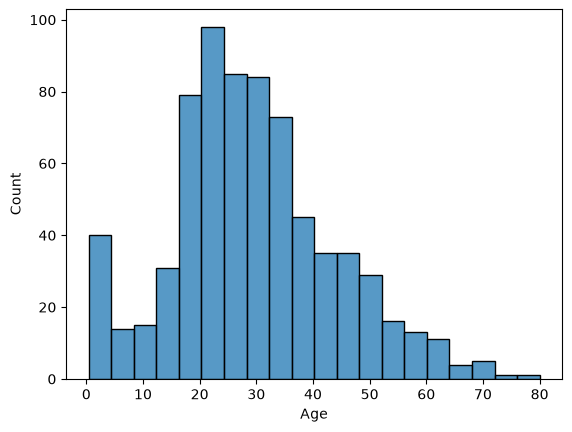

In [ ]:
sns.histplot(df['Age'])

<Axes: xlabel='Age', ylabel='Density'>

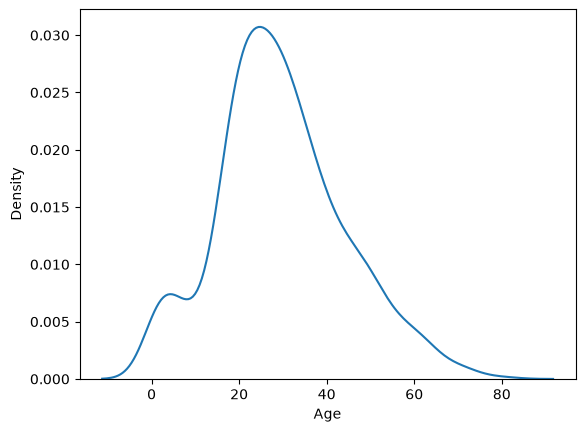

In [ ]:
sns.kdeplot(df['Age'])
# This tells us about the skewness of our df!


In [ ]:
# In order to find the skew of our df --> 
df['Age'].skew()

# Since the value is near about 0, we can say that our df is normal, which is a good thing,
# because in future, when we will be applying many statistical tests, they assume that our df is already normal distribution 
# Therefore, this is a good thing!

np.float64(0.38910778230082704)

<Axes: ylabel='Age'>

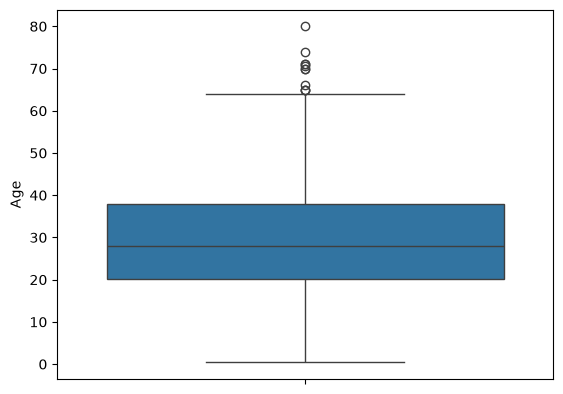

In [ ]:
sns.boxplot(df['Age'])

In [ ]:
# Now from this we can see the outliers in our df! 
# But to verify, whether these are genuinely outliers, or by mistake they have been considered as outliers, 
# we have to see the df for that!
# What I mean by this is that, let's say there's an age of 300 in our df by mistake, then that's obviously an outlier, but other values, like 
# here we can see that any value above around 65 is an outlier. But what if these are actually the ages from 65-80 of some genuine people
# Then in that case, we cannot consider this as an outlier

# To see this, we have to do --> 

df[df['Age'] > 65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [ ]:
# Now let's see if we have missing values as well!

print(len(df['Age']))
print(df['Age'].isnull().sum())        # We ahve total of 177 missing values from a total of 891!

print(df['Age'].isnull().sum() / len(df['Age']))        # Around 19% of values from our df is missing, which is too much!

891
177
0.19865319865319866


### Fare

**conclusions** - 

1. df is highly skewed (Positively skewed)
2. Fare column actually contains the group fare and not the individual fare. (This might be an issue)
3. We need to create a new column called 'individual_fare'

In [ ]:
df['Fare'].describe()

In [ ]:
sns.histplot(df['Fare'])

In [ ]:
sns.kdeplot(df['Fare'])

# We can say that, our df is 'Negatively Skewed' (OR left-skewed)

In [ ]:
df['Fare'].skew()
# Since this value is greater than 0, it is highly positively skewed distribution!

In [ ]:
# Identifying outliers
sns.boxplot(df['Fare'])

# As we can see, there are too many outliers in our df!
# Roughly any value above 100-200 $ is an outlier!


In [ ]:
df[df['Fare'] > 250]

# As you can see from the df, what we were assuming is that, the 'Fare' column is the ticket price each person has paid!
# But in reality, it's the total price that the entire family (if travelling along with family) has paid!
# Therefore, there are no outliers as such, rather, these are families travelling together and that's the reason why their 'Fare' price is so high!

In [ ]:
# Now in future, we will have to perform feature engineering to somehow calculate the 'Fare' for each person travelling on the ship!

In [ ]:
df['Fare'].isnull().sum()

### Steps of doing Univariate Analysis on Categorical columns

**Descriptive Statistics**: Compute the frequency distribution of the categories in the column. This will give a general understanding of the distribution of the categories and their relative frequencies.

**Visualizations**: Create visualizations to explore the distribution of the categories. Some common visualizations for categorical df include count plots and pie charts. These visualizations provide a visual representation of the distribution of the categories and can help identify any patterns or anomalies in the df.

**Missing Values**: Check for missing values in the df and decide how to handle them. Missing values can be imputed or excluded from the analysis, depending on the research question and the df set.

**Conclusion**: Summarize the findings of the EDA and make decisions about how to proceed with further analysis.

### Survived

**conclusions** - 

1.  The accident was so deadly that nearly 62% of the people on the ship were dead and only 38% of the people survived it!

In [ ]:
df['Survived'].value_counts()

# 0 - people died
# 1 - people survived

In [ ]:
sns.barplot(df['Survived'].value_counts())
# sns.catplot(df['Survived'].value_counts(), kind='bar')

In [ ]:
labels = ['Dead', 'Survived']
plt.pie(df['Survived'].value_counts(), labels=labels, autopct='%0.1f%%')
plt.legend()

In [ ]:
df['Survived'].isnull().sum()

### Pclass

**conclusions** - 
1. Surprisingly more people travelled in Pclass-1 and less people travelled in Pclass-2

In [ ]:
df['Pclass'].value_counts()
# 3 - Middle class
# 1 - Rich people
# 2 - Upper middle class

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [ ]:
sns.barplot(df['Pclass'].value_counts())
# sns.catplot(cata['Pclass'].value_counts(), kind='bar')

In [ ]:
labels = ['Middle Class', 'Rich people', 'Upper Middle Class']
plt.pie(df['Pclass'].value_counts(), labels=labels, autopct='%0.1f%%')

In [ ]:
df['Pclass'].isnull().sum()

### Sex

**conclusions** - 

In [ ]:
df['Sex'].value_counts()

In [ ]:
sns.barplot(df['Sex'].value_counts())
# sns.catplot(df['Sex'].value_counts(), kind='bar')

In [ ]:
labels = ['Male', 'Female']
plt.pie(df['Sex'].value_counts(), labels=labels, autopct='%0.1f%%')

In [ ]:
df['Sex'].isnull().sum()

###  SibSp & Parch

**conclusions** - 
1. 

In [ ]:
df['SibSp'].value_counts()

In [ ]:
sns.barplot(df['SibSp'].value_counts())
# sns.catplot(df['SibSp'].value_counts(), kind='bar')

In [ ]:
labels = ['0', '1', '2', '4', '3', '8', '5']
plt.pie(df['SibSp'].value_counts(), labels=labels, autopct='%0.1f%%')

In [ ]:
df['SibSp'].isnull().sum()

### Parch

**conclusions** -
1. 'Parch' and 'SibSp' can be merged to form a new column called 'family_size'
2. We can create a new column called 'is_alone'

In [ ]:
df['Parch'].value_counts()

In [ ]:
sns.barplot(df['Parch'].value_counts())
# sns.catplot(df['Parch'].value_counts(), kind='bar')

In [ ]:
labels = ['0', '1', '2', '5', '3', '4', '6']
plt.pie(df['Parch'].value_counts(), labels=labels, autopct='%0.1f%%')

In [ ]:
df['Parch'].isnull().sum()

### Embarked

**concludions** - 
1. 

In [ ]:
df['Embarked'].value_counts()

# S - Southampton (Departure)
# C - Cherbourg (First Stop)
# Q - Queenstown (Second Stop)

In [ ]:
sns.barplot(df['Embarked'].value_counts())
# sns.catplot(df['Embarked'].value_counts(), kind='bar')

In [ ]:
labels = ['Southampton', 'Cherbourg', 'Queenstown']
plt.pie(df['Embarked'].value_counts(), labels=labels, autopct='%0.1f%%')

### Univariate analysis on Mixed Columns

In order to do univariate analysis on mixed columns, we have to first do feature engineering and convert them into a simpler form such that we can then perform univariate analysis on them!


Basically convert them into categorical or numerical df!

### Steps of doing Bivariate Analysis

- Select 2 cols
- Understand type of relationship
    1. **Numerical - Numerical**<br>
        a. You can plot graphs like scatterplot(regression plots), 2D histplot, 2D KDEplots<br>
        b. Check correlation coefficent to check linear relationship
    2. **Numerical - Categorical** - create visualizations that compare the distribution of the numerical df across different categories of the categorical df.<br>
        a. You can plot graphs like barplot, boxplot, kdeplot violinplot even scatterplots<br>
    3. **Categorical - Categorical**<br>
        a. You can create cross-tabulations or contingency tables that show the distribution of values in one categorical column, grouped by the values in the other categorical column.<br>
        b. You can plots like heatmap, stacked barplots, treemaps
        
- Write your conclusions

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# While doing bivariate analysis, what we should do is, select the most important column in our dfframe.
# Because we are doing survival prediction (ML Model), the most important column would be 'Survived'
# Now we have to plot a graph between 'Survived' and all the rest of the columns 
# We should only plot a graph only if it's meaningful, not just for the sake of doing it!

In [5]:
# Another import column is 'Age' because there are a few missing values and also there can be a relationship that can be drawn, 
# between the 2 columns

### Survived v/s Pclass

**conclusions** - <br> 
Thus, we can surely say that, travelling in Pclass 3 was very dangerous as compared to Pclass 1 as nearly 76% people died

<Axes: xlabel='Pclass', ylabel='Survived'>

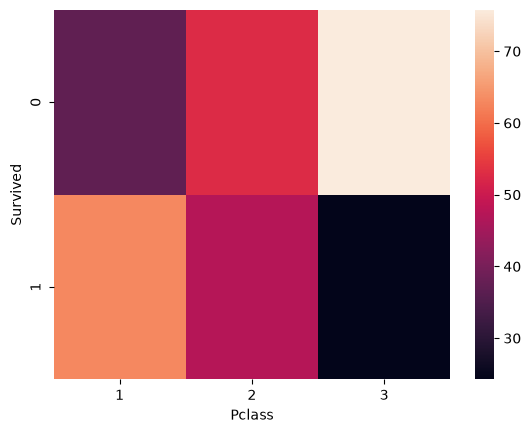

In [ ]:
# Now first let's select 2 columns - 'Survived' and 'Pclass'
# Both are categorical
# Therefore, we'll have to create a crosstab between the two!


pd.crosstab(df['Survived'], df['Pclass'])

# Now instead of talking in terms of absolute numbers, let's talk in terms of percentages
# In order to do that - 

# pd.crosstab(df['Survived'], df['Pclass'], normalize='columns')*100
sns.heatmap(pd.crosstab(df['Survived'], df['Pclass'], normalize='columns')*100)

Sex          female       male
Survived                      
0         25.796178  81.109185
1         74.203822  18.890815


<Axes: xlabel='Sex', ylabel='Survived'>

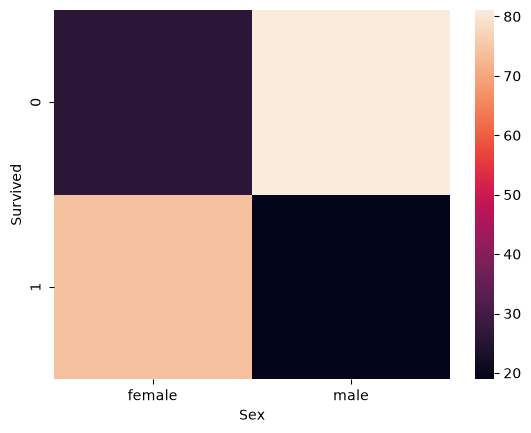

In [ ]:
# Survived v/s Sex

print(pd.crosstab(df['Survived'], df['Sex'], normalize='columns')*100)
sns.heatmap(pd.crosstab(df['Survived'], df['Sex'], normalize='columns')*100)

Embarked          C          Q          S
Survived                                 
0         44.642857  61.038961  66.304348
1         55.357143  38.961039  33.695652


<Axes: xlabel='Embarked', ylabel='Survived'>

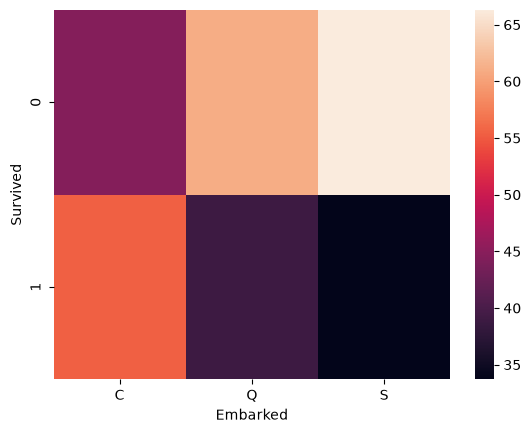

In [ ]:
# Survived v/s Embarked

print(pd.crosstab(df['Survived'], df['Embarked'], normalize='columns')*100)
sns.heatmap(pd.crosstab(df['Survived'], df['Embarked'], normalize='columns')*100)

In [20]:
# By looking at the above graph we can kinda say that percentage of people who survived, are from Cherbourg. 
# 
# But what could be the reason? 
# Is it that because most of them were females? 
# OR 
# Is it because most of them are from Pclass 1

# Let's check!

In [ ]:
print(pd.crosstab(df['Sex'], df['Embarked'], normalize='columns')*100)

Embarked          C          Q          S
Sex                                      
female    43.452381  46.753247  31.521739
male      56.547619  53.246753  68.478261


In [23]:
# This couldn't be the case because, the number of females were nearly 44%
# So let's check if the reason for survival was Pclass!?

In [ ]:
print(pd.crosstab(df['Pclass'], df['Embarked'], normalize='columns')*100)

Embarked          C          Q          S
Pclass                                   
1         50.595238   2.597403  19.720497
2         10.119048   3.896104  25.465839
3         39.285714  93.506494  54.813665


In [ ]:
# Yes by looking at the above insight, we can conclude that the reason for survival was truly becuase of Pclass! 

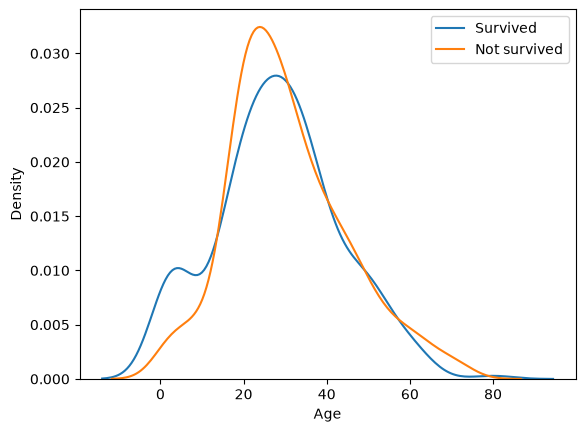

In [ ]:
# Numerical - Categorical

# Survived v/s Age
sns.kdeplot(df[df['Survived'] == 1]['Age'], label='Survived')
sns.kdeplot(df[df['Survived'] == 0]['Age'], label='Not survived')
plt.legend()

In [ ]:
df[df['Pclass']==1]['Age'].mean()

np.float64(38.233440860215055)

### Feature Engineering

In [ ]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [ ]:
df[df['SibSp'] == 8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [ ]:
# The above table tells us that there's a family of 11 (Consider Sage, Thomas Henry and 8+2+1(himself) = 11), 
# who are travelling together (Look at the surnames, 'Sage')!
# Everyones fares are same
# But the concern is that, out of 11, only 7 people are shown here
# That could only mean that, either the remaining 4 have booked using a diff. ticket or there's no df available! 

In [ ]:
df[df['Name'].str.contains('Sage')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
641,642,1,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.30,B35,C
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [80]:
df1 = pd.read_csv('Datasets/test.csv')
df1.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [81]:
df = pd.concat([df, df1])

In [82]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [84]:
df[df['Ticket'] == "CA. 2343"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S


In [85]:
df[df['Ticket'] == "CA 2144"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
59,60,0.0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9,NaN,S
71,72,0.0,3,"Goodwin, Miss. Lillian Amy",female,16.0,5,2,CA 2144,46.9,NaN,S
386,387,0.0,3,"Goodwin, Master. Sidney Leonard",male,1.0,5,2,CA 2144,46.9,NaN,S
480,481,0.0,3,"Goodwin, Master. Harold Victor",male,9.0,5,2,CA 2144,46.9,NaN,S
678,679,0.0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,CA 2144,46.9,NaN,S
683,684,0.0,3,"Goodwin, Mr. Charles Edward",male,14.0,5,2,CA 2144,46.9,NaN,S
139,1031,NaN,3,"Goodwin, Mr. Charles Frederick",male,40.0,1,6,CA 2144,46.9,NaN,S
140,1032,NaN,3,"Goodwin, Miss. Jessie Allis",female,10.0,5,2,CA 2144,46.9,NaN,S


In [86]:
df['individual_fare'] = df['Fare'] / (df['SibSp'] + df['Parch'] + 1)

<Axes: ylabel='individual_fare'>

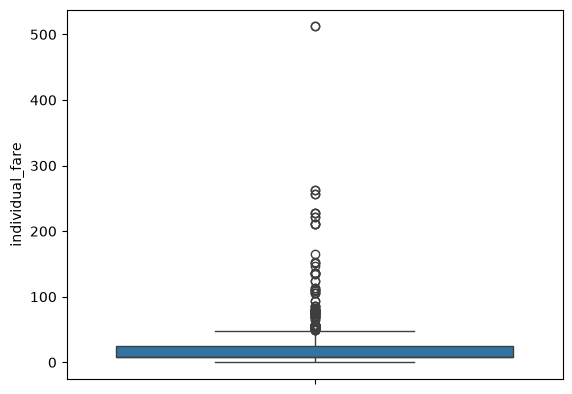

In [87]:
sns.boxplot(df['individual_fare'])

In [88]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000


In [89]:
df['family_size'] = df['SibSp'] + df['Parch'] + 1

In [90]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.62500,2
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.92500,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.05000,1


In [91]:
# Now we are creating a new column called 'family_type' 

# 1 --> alone
# 2-4 --> small
# >5 --> large

def transform_family_size(num):
    if (num == 1):
        return 'alone'
    elif (num > 1 and num < 5):
        return 'small'
    else:
        return 'large'

In [92]:
df['family_type'] = df['family_size'].apply(transform_family_size)

In [93]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.625000,2,small
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.641650,2,small
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000,1,alone
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.550000,2,small
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.050000,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,8.050000,1,alone
414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,108.900000,1,alone
415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000,1,alone
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000,1,alone


In [96]:
print(df.index.is_unique)

False


In [97]:
df = df.reset_index(drop=True)

In [98]:
pd.crosstab(df['Survived'], df['family_type'], normalize='columns')*100

family_type,alone,large,small
Survived,,,
0.0,69.646182,83.870968,42.123288
1.0,30.353818,16.129032,57.876712


In [103]:
df['surname'] = df['Name'].str.split(',').str[0]

In [104]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,surname
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.625000,2,small,Braund
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.641650,2,small,Cumings
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000,1,alone,Heikkinen
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.550000,2,small,Futrelle
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.050000,1,alone,Allen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,8.050000,1,alone,Spector
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,108.900000,1,alone,Oliva y Ocana
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000,1,alone,Saether
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000,1,alone,Ware


In [127]:
df['title'] = df['Name'].str.split(',').str.get(1).str.strip().str.split(' ').str.get(0)

In [129]:
df['title'].value_counts()

title
Mr.          757
Miss.        260
Mrs.         197
Master.       61
Rev.           8
Dr.            8
Col.           4
Ms.            2
Major.         2
Mlle.          2
Don.           1
Mme.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Dona.          1
Name: count, dtype: int64

In [130]:
df['title'] = df['title'].str.replace('Rev.','other')
df['title'] = df['title'].str.replace('Dr.','other')
df['title'] = df['title'].str.replace('Col.','other')
df['title'] = df['title'].str.replace('Major.','other')
df['title'] = df['title'].str.replace('Capt.','other')
df['title'] = df['title'].str.replace('the','other')
df['title'] = df['title'].str.replace('Jonkheer.','other')

In [132]:
df['title'].value_counts()

title
Mr.        757
Miss.      260
Mrs.       197
Master.     61
ootherr     23
Ms.          2
Mlle.        2
other        2
Don.         1
Mme.         1
Lady.        1
Sir.         1
Dona.        1
Name: count, dtype: int64

In [133]:
temp_df = df[df['title'].isin(['Mr.', 'Miss.', 'Mrs.', 'Master.', 'ootherr'])]

In [135]:
pd.crosstab(temp_df['Survived'], temp_df['title'], normalize='columns')*100

title,Master.,Miss.,Mr.,Mrs.,ootherr
Survived,,,,,
0.0,42.5,30.21978,84.332689,20.8,72.222222
1.0,57.5,69.78022,15.667311,79.2,27.777778


In [ ]:
print((df['Cabin'].isnull().sum() / len(df['Cabin'])) * 100)

# These many missing values, but this is one of the important columns
# Many people drop this because, since we cannot fill the cabin values
# But there's a lot of information hiding in the 'Cabin' column! 

77.46371275783041


In [139]:
df['Cabin'].value_counts().head(15)

Cabin
C23 C25 C27        6
G6                 5
B57 B59 B63 B66    5
F33                4
F2                 4
F4                 4
C78                4
D                  4
C22 C26            4
B96 B98            4
B58 B60            3
E101               3
E34                3
A34                3
C101               3
Name: count, dtype: int64

In [ ]:
# Let's do one thing
# Let's try to find the Survival percentage from the cabin!
# To do that, let's extract the Cabin of those whose cabin names we've got (only A, B, C, D, E, F, G and T cabins were there (Checkout wikipedia.org for more info))
# And let's assign 'M' as ('Missing') for those whose Cabin names are missing! 

In [142]:
df['Cabin'] = df['Cabin'].fillna('M')

In [143]:
df['Cabin'].value_counts()

Cabin
M                  1014
C23 C25 C27           6
G6                    5
B57 B59 B63 B66       5
F33                   4
                   ... 
C39                   1
B24                   1
D40                   1
D38                   1
C105                  1
Name: count, Length: 187, dtype: int64

In [144]:
df['deck'] = df['Cabin'].str[0]

In [146]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,individual_fare,family_size,family_type,surname,title,deck
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,M,S,3.62500,2,small,Braund,Mr.,M
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.64165,2,small,Cumings,Mrs.,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,M,S,7.92500,1,alone,Heikkinen,Miss.,M
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.55000,2,small,Futrelle,Mrs.,C
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,M,S,8.05000,1,alone,Allen,Mr.,M


In [147]:
df['deck'].value_counts()

deck
M    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64

In [148]:
# Also let's see which Pclass passengers were travelling in which deck!
pd.crosstab(df['deck'], df['Pclass'])

Pclass,1,2,3
deck,,,
A,22,0,0
B,65,0,0
C,94,0,0
D,40,6,0
E,34,4,3
F,0,13,8
G,0,0,5
M,67,254,693
T,1,0,0


In [ ]:
pd.crosstab(df['Survived'], df['deck'], normalize='columns')*100


deck,A,B,C,D,E,F,G,M,T
Survived,,,,,,,,,
0.0,53.333333,25.531915,40.677966,24.242424,25.0,38.461538,50.0,70.014556,100.0
1.0,46.666667,74.468085,59.322034,75.757576,75.0,61.538462,50.0,29.985444,0.0


<Axes: xlabel='deck'>

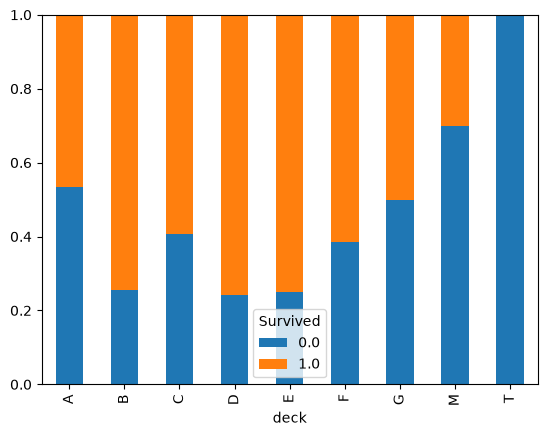

In [150]:
pd.crosstab(df['deck'], df['Survived'], normalize='index').plot(kind='bar', stacked=True)


<Axes: >

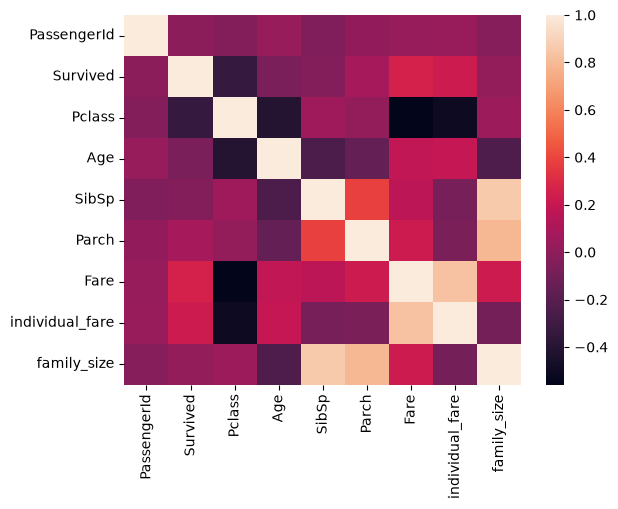

In [157]:
sns.heatmap(df.corr(numeric_only=True))

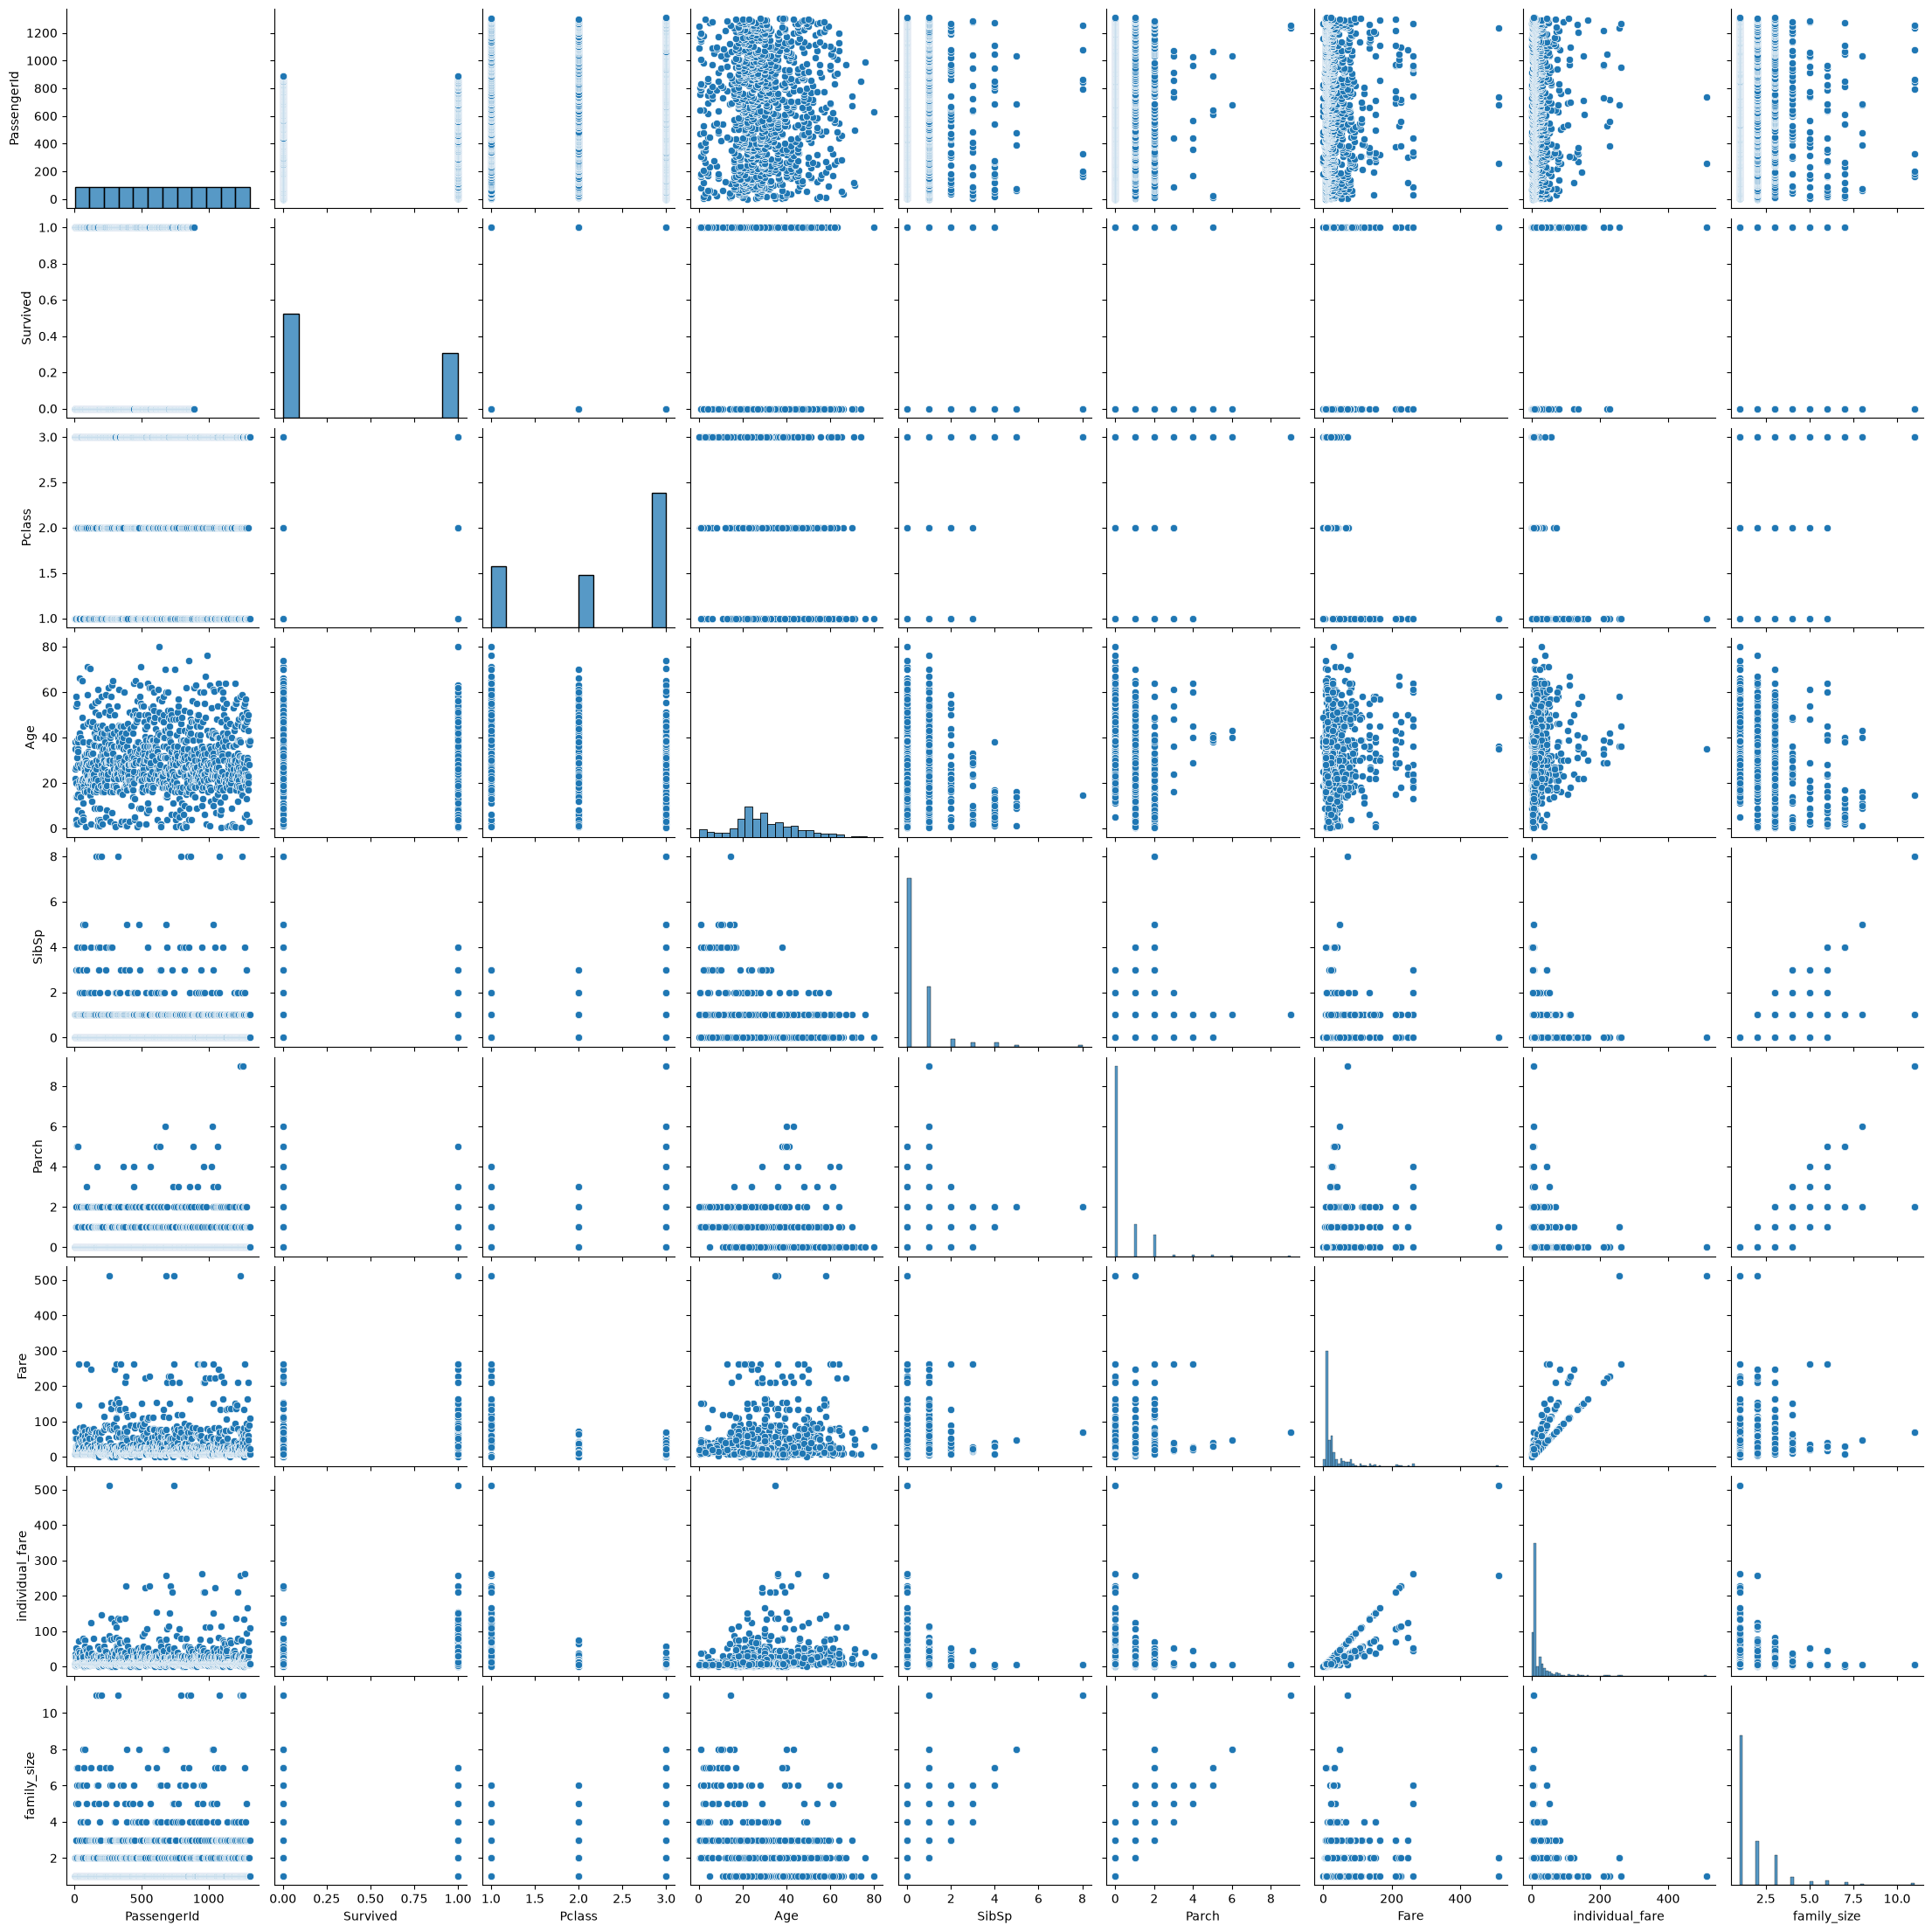

In [154]:
sns.pairplot(df)